# Hands-On 6: Comparing classification performance

Worked responses accompany the same experiments.

In [1]:
from pathlib import Path
import os
import sys
try:
    import mlcourse.setup
except ModuleNotFoundError:
    bases = [Path(os.environ.get("MLCOURSE_ROOT", Path.cwd())), Path.cwd(), Path("/content/pp-machine-learning")]
    for base in bases:
        for candidate in (base.resolve(), *base.resolve().parents):
            if (candidate / "src/mlcourse/setup.py").is_file():
                sys.path.insert(0, str(candidate / "src"))
                break
        else:
            continue
        break
    else:
        raise RuntimeError("Course files not found. Open the extracted course repository or set MLCOURSE_ROOT to its location.") from None

In [2]:
from mlcourse.setup import setup_notebook
REPO_ROOT = setup_notebook()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from mlcourse.labs import load_course_data

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import friedmanchisquare
from mlcourse.labs import load_task_results

## 1. Inspect three tasks

Load `ds1`, `ds2` and `ds3`. Inspect their dimensions and class counts.

**Prediction:** Should one classifier necessarily perform best on all three tasks?

No. The relative performance can depend on how each model family matches the task geometry.

In [3]:
datasets = {name: load_course_data(name) for name in ['ds1', 'ds2', 'ds3']}
display(pd.DataFrame({name: frame.Class.value_counts().sort_index() for name, frame in datasets.items()}))
display(pd.DataFrame([{'dataset': name, 'rows': len(frame), 'predictors': 2} for name, frame in datasets.items()]))

,ds1,ds2,ds3
Class,,,
0,67,66,66
1,67,68,66
2,66,66,68


,dataset,rows,predictors
0,ds1,200,2
1,ds2,200,2
2,ds3,200,2


**Observation:** Do these tasks have the same sizes and class representation?

The tables show equal task sizes and broadly comparable class counts. They do not describe the arrangement of the features.

**Explanation:** Why can comparable class counts conceal different learning difficulty?

Class counts omit separation, overlap and boundary shape. Those properties can favour different model assumptions.

## 2. Run shared cross-validation folds

Use ten stratified folds to evaluate seven classifiers. Fit scaling inside each training fold.

**Prediction:** Why use the same folds for every classifier?

Shared folds evaluate the models on matching held-out observations.

In [4]:
models = {'k-NN': make_pipeline(StandardScaler(), KNeighborsClassifier()),
          'Tree': DecisionTreeClassifier(random_state=0),
          'LDA': LinearDiscriminantAnalysis(), 'Naive Bayes': GaussianNB(),
          **{f'SVM {kernel}': make_pipeline(StandardScaler(), SVC(kernel=kernel)) for kernel in ['linear', 'poly', 'rbf']}}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
fold_results = {}
for name, frame in datasets.items():
    fold_results[name] = pd.DataFrame({label: cross_val_score(model, frame[['X1', 'X2']], frame.Class,
        cv=cv, scoring='accuracy') for label, model in models.items()})
display(fold_results['ds2'])

,k-NN,Tree,LDA,Naive Bayes,SVM linear,SVM poly,SVM rbf
0,0.850,0.900,0.900,0.900,0.900,0.900,0.900
1,0.750,0.650,0.750,0.750,0.800,0.600,0.750
2,0.900,0.900,0.700,0.850,0.850,0.750,0.850
3,0.800,0.850,0.800,0.700,0.800,0.700,0.750
4,0.900,0.800,0.950,0.900,0.950,0.900,0.950
5,0.900,0.850,0.900,0.950,0.900,0.800,0.900
6,0.950,0.800,0.850,0.950,0.950,0.900,0.950
7,0.900,0.950,0.850,0.800,0.800,0.850,0.800
8,0.800,0.750,0.900,0.850,0.900,0.850,0.900
9,0.900,0.850,0.850,0.850,0.800,0.800,0.850


**Observation:** What does one row of this result table represent?

Each row contains the accuracies from one held-out fold for every model. Each column contains ten estimates for one configuration.

**Explanation:** Why is scaling learned separately within each training fold?

Learning scaling inside the training fold avoids using information from its held-out observations. The fitted transformation is then applied to those held-out observations.

## 3. Summarise performance and variability

Compute mean accuracy and standard deviation for `ds2`.

**Prediction:** Can two models have similar means but different variability?

Yes. Similar average accuracy can arise from either stable scores or widely varying scores.

In [5]:
summary = pd.DataFrame({'mean_accuracy': fold_results['ds2'].mean(),
                        'standard_deviation': fold_results['ds2'].std(ddof=1)})
display(summary.sort_values('mean_accuracy', ascending=False))

,mean_accuracy,standard_deviation
k-NN,0.865,0.063
SVM linear,0.865,0.063
SVM rbf,0.860,0.074
Naive Bayes,0.850,0.082
LDA,0.845,0.076
Tree,0.830,0.086
SVM poly,0.805,0.098


**Observation:** Find a close mean comparison and compare its standard deviations.

k-NN and linear SVM both have mean accuracy 0.865 and standard deviation 0.063. RBF SVM has a nearby mean of 0.860 with a larger standard deviation of 0.074.

**Explanation:** What information is lost when only the mean is reported?

A mean hides which partitions were easier or harder and how sensitive the fitted rule was to the sample. Standard deviation is a descriptive measure of that variation.

## 4. Compare the score distributions

Plot the fold-wise results. Use the scores to describe estimated performance and its variability.

**Prediction:** Will the ordering by mean describe every fold?

No. Individual fold scores can overlap even when their averages differ.

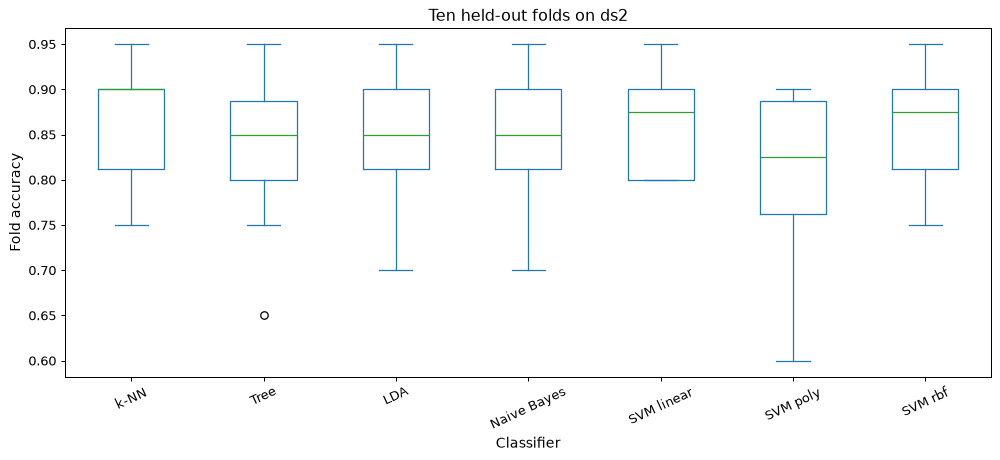

,ds1,ds2,ds3
k-NN,1.000,0.865,0.860
Tree,1.000,0.830,0.900
LDA,1.000,0.845,0.325
Naive Bayes,1.000,0.850,0.905
SVM linear,1.000,0.865,0.420
SVM poly,0.995,0.805,0.445
SVM rbf,1.000,0.860,0.925


In [9]:
fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
fold_results['ds2'].plot.box(ax=ax, rot=25)
ax.set(xlabel='Classifier', ylabel='Fold accuracy', title='Ten held-out folds on ds2')
plt.show()
display(pd.DataFrame({name: scores.mean() for name, scores in fold_results.items()}))

**Observation:** Compare distribution overlap and the ordering across the three tasks.

The ds2 boxes overlap substantially. Across tasks, LDA falls from 1.000 on ds1 to 0.325 on ds3, while RBF SVM scores 0.925 on ds3, illustrating how ordering depends on task geometry.

**Explanation:** Why should a small mean difference be interpreted with the observed variability?

A small difference may be sensitive to the particular sampled observations. These scores describe estimated performance and variation under this evaluation setup.

## 5. Compare ten dataset-level results

Load the provided results for ten tasks. Average within each task and rank classifiers, with rank `1` assigned to the highest accuracy.

**Prediction:** Will averaging accuracy and averaging ranks necessarily give the same ordering?

No. Ranks retain ordering within a task but discard the size of the accuracy differences.

In [7]:
task_means = load_task_results()
ranks = task_means.rank(axis=1, ascending=False, method='average')
display(task_means)
display(ranks)

,knn,dt,lda,gnb,linear_svc,poly_svc,rbf_svc
results_ds1,1.000,1.000,1.000,1.000,1.000,1.000,1.000
results_ds2,0.880,0.820,0.845,0.860,0.845,0.835,0.865
results_ds3,0.875,0.875,0.305,0.920,0.340,0.390,0.930
results_ds4,0.895,0.890,0.910,0.890,0.920,0.880,0.925
results_ds5,0.880,0.820,0.845,0.860,0.845,0.835,0.865
results_ds6,0.875,0.870,0.305,0.920,0.340,0.390,0.930
results_ds7,0.935,0.875,0.910,0.910,0.915,0.855,0.915
results_ds8,0.890,0.880,0.910,0.905,0.905,0.880,0.905
results_ds9,0.960,0.920,0.915,0.935,0.940,0.915,0.950
results_ds10,0.950,0.920,0.955,0.955,0.945,0.920,0.945


,knn,dt,lda,gnb,linear_svc,poly_svc,rbf_svc
results_ds1,4.000,4.000,4.000,4.000,4.000,4.000,4.000
results_ds2,1.000,7.000,4.500,3.000,4.500,6.000,2.000
results_ds3,3.500,3.500,7.000,2.000,6.000,5.000,1.000
results_ds4,4.000,5.000,3.000,6.000,2.000,7.000,1.000
results_ds5,1.000,7.000,4.500,3.000,4.500,6.000,2.000
results_ds6,3.000,4.000,7.000,2.000,6.000,5.000,1.000
results_ds7,1.000,6.000,4.500,4.500,2.500,7.000,2.500
results_ds8,5.000,6.500,1.000,3.000,3.000,6.500,3.000
results_ds9,1.000,5.000,6.500,4.000,3.000,6.500,2.000
results_ds10,3.000,6.500,1.500,1.500,4.500,6.500,4.500


**Observation:** Identify a tied rank and a change in ordering between tasks.

All algorithms tie on the first task and receive rank 4.000. k-NN ranks first on the second task, while RBF SVM ranks first on the third.

**Explanation:** What changes when one observation is an entire dataset?

A dataset-level comparison asks how algorithms perform across learning problems. It gives each task one summary rather than treating its folds as separate tasks.

## 6. Summarise ranks and the Friedman test

Run one Friedman test on the dataset-level means and plot average ranks.

**Prediction:** Does the algorithm with best average rank necessarily win every task?

No. Good average rank can combine strong results on some tasks with weaker results on others.

Friedman statistic: 27.502; p-value: 0.000117


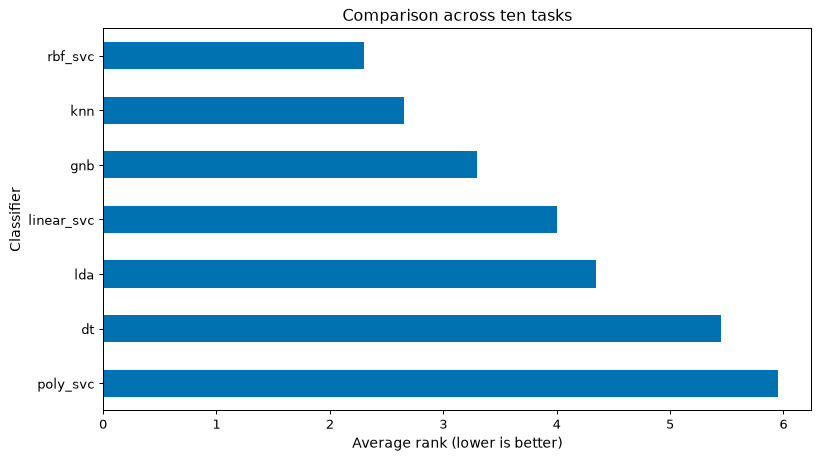

rbf_svc      2.300
knn          2.650
gnb          3.300
linear_svc   4.000
lda          4.350
dt           5.450
poly_svc     5.950
Name: average_rank, dtype: float64

In [8]:
statistic, pvalue = friedmanchisquare(*(task_means[column] for column in task_means))
print(f'Friedman statistic: {statistic:.3f}; p-value: {pvalue:.3g}')
mean_ranks = ranks.mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')
mean_ranks.plot.barh(ax=ax, color='#0072B2')
ax.invert_yaxis()
ax.set(xlabel='Average rank (lower is better)', ylabel='Classifier', title='Comparison across ten tasks')
plt.show()
display(mean_ranks.rename('average_rank'))

**Observation:** Report the best average rank and interpret the p-value at `0.050`.

RBF SVM has the best average rank, 2.300. The p-value is approximately 0.000117, below 0.050, providing omnibus evidence against equal performance under the test assumptions.

**Explanation:** What does an omnibus result establish about these algorithms?

The omnibus test assesses the collection as a whole under its assumptions. It does not identify which particular algorithm pairs differ, and these ten tasks do not establish universal superiority.